# Hibrit Model Eğitimi — ResNet50 + CNN+kNN + CNN+SVM
**Hedef:** Her model için %90+ doğruluk

**Veri:** `/content/drive/MyDrive/YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined`

**Kayıt:** `/content/drive/MyDrive/Hap_Modelleri_V3`

| Dosya | Açıklama |
|---|---|
| `resnet50_hap_modeli.h5` | ResNet50 eğitilmiş model |
| `cnn_knn_model.joblib` | CNN+kNN hibrit model |
| `cnn_svm_model.joblib` | CNN+SVM hibrit model |
| `scaler_feat.joblib` | Feature ölçekleyici |
| `label_encoder.joblib` | Etiket encoder |

In [1]:
# ── KOD HÜCRESİ 1: Drive Bağlantısı ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive baglandi!')

Mounted at /content/drive
Drive baglandi!


In [2]:
# ── KOD HÜCRESİ 2: Kütüphaneler ───────────────────────────────────────────
import os, cv2, numpy as np, warnings, joblib, gc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K

warnings.filterwarnings('ignore')
print('Kutuphaneler yuklendi. TF:', tf.__version__)

Kutuphaneler yuklendi. TF: 2.19.0


In [3]:
# ── KOD HÜCRESİ 3: Yollar ──────────────────────────────────────────────────
VERI_YOLU = '/content/drive/MyDrive/YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined'
MODEL_DIR = '/content/drive/MyDrive/Hap_Modelleri_V3'
os.makedirs(MODEL_DIR, exist_ok=True)

SEED = 42

siniflar = sorted([
    s for s in os.listdir(VERI_YOLU)
    if os.path.isdir(os.path.join(VERI_YOLU, s))
])
N_SINIF = len(siniflar)
print('Siniflar:', siniflar)
print('Sinif sayisi:', N_SINIF)

Siniflar: ['Alaxan', 'Bactidol', 'Bioflu', 'Biogesic', 'DayZinc', 'Decolgen', 'Fish Oil', 'Kremil S', 'Medicol', 'Neozep']
Sinif sayisi: 10


In [4]:
# ── KOD HÜCRESİ 4: Veri Yükleme (96x96, Augmentation Yok) ─────────────────
print('Veriler yukleniyor...')
X_all, y_all = [], []

for sinif_adi in siniflar:
    yol = os.path.join(VERI_YOLU, sinif_adi)
    for resim_adi in sorted(os.listdir(yol)):
        if not resim_adi.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
            continue
        r = cv2.imread(os.path.join(yol, resim_adi))
        if r is None:
            continue
        r = cv2.resize(r, (96, 96))
        X_all.append(cv2.cvtColor(r, cv2.COLOR_BGR2RGB).astype('float32') / 255.0)
        y_all.append(sinif_adi)

X_all = np.array(X_all)
y_all = np.array(y_all)

le = LabelEncoder()
le.fit(siniflar)
y_num = le.transform(y_all)

joblib.dump(le, os.path.join(MODEL_DIR, 'label_encoder.joblib'))
print('Toplam goruntu:', len(X_all))
for s in siniflar:
    print(' ', s, ':', np.sum(y_all == s))

Veriler yukleniyor...
Toplam goruntu: 10000
  Alaxan : 1000
  Bactidol : 1000
  Bioflu : 1000
  Biogesic : 1000
  DayZinc : 1000
  Decolgen : 1000
  Fish Oil : 1000
  Kremil S : 1000
  Medicol : 1000
  Neozep : 1000


In [5]:
# ── KOD HÜCRESİ 5: 8000 Train / 2000 Test Bölme ───────────────────────────
X_train, X_test, y_train_num, y_test_num = train_test_split(
    X_all, y_num,
    test_size=2000,
    train_size=8000,
    random_state=SEED,
    stratify=y_num
)
y_train_cat = tf.keras.utils.to_categorical(y_train_num, num_classes=N_SINIF)
y_test_cat  = tf.keras.utils.to_categorical(y_test_num,  num_classes=N_SINIF)

print('Egitim:', X_train.shape, '| Test:', X_test.shape)

Egitim: (8000, 96, 96, 3) | Test: (2000, 96, 96, 3)


In [6]:
# ── KOD HÜCRESİ 6: ResNet50 — Veri Hazırlama (224x224) ────────────────────
print('ResNet50 icin goruntüler hazirlaniyor (224x224)...')
X_train_rn = np.array([
    resnet_pre(cv2.resize((img*255).astype('uint8'), (224,224)).astype('float32'))
    for img in X_train
])
X_test_rn = np.array([
    resnet_pre(cv2.resize((img*255).astype('uint8'), (224,224)).astype('float32'))
    for img in X_test
])
print('Egitim (224x224):', X_train_rn.shape)
print('Test   (224x224):', X_test_rn.shape)

ResNet50 icin goruntüler hazirlaniyor (224x224)...
Egitim (224x224): (8000, 224, 224, 3)
Test   (224x224): (2000, 224, 224, 3)


In [7]:
# ── KOD HÜCRESİ 7: ResNet50 — Model ve Aşama 1 Eğitimi ────────────────────
print('ResNet50 modeli kuruluyor...')
K.clear_session()

base_rn = ResNet50(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_rn.trainable = False

inp_rn = Input(shape=(224,224,3))
x_rn   = base_rn(inp_rn, training=False)
x_rn   = GlobalAveragePooling2D()(x_rn)
x_rn   = BatchNormalization()(x_rn)
x_rn   = Dense(512, activation='relu')(x_rn)
x_rn   = Dropout(0.3)(x_rn)
x_rn   = Dense(256, activation='relu', name='feat_layer_rn')(x_rn)
x_rn   = Dropout(0.3)(x_rn)
out_rn = Dense(N_SINIF, activation='softmax', dtype='float32')(x_rn)

model_rn = Model(inp_rn, out_rn)
model_rn.compile(
    optimizer=Adam(1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

kayit_rn = os.path.join(MODEL_DIR, 'resnet50_hap_modeli.h5')
cb_rn_1 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                     patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(kayit_rn, save_best_only=True,
                    monitor='val_accuracy', verbose=0)
]

print('Asama 1: Ust katmanlar egitiliyor (25 epoch max)...')
hist_rn_1 = model_rn.fit(
    X_train_rn, y_train_cat,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=cb_rn_1,
    verbose=1
)
print('Asama 1 tamamlandi. En iyi val_acc: %' +
      str(round(max(hist_rn_1.history['val_accuracy'])*100, 2)))

ResNet50 modeli kuruluyor...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Asama 1: Ust katmanlar egitiliyor (25 epoch max)...
Epoch 1/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4993 - loss: 1.7205

225/225 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.6044 - loss: 1.3788 - val_accuracy: 0.7688 - val_loss: 0.9650 - learning_rate: 0.0010
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7809 - loss: 0.9182

225/225 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.7740 - loss: 0.9327 - val_accuracy: 0.7925 - val_loss: 0.8604 - learning_rate: 0.0010
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8252 - loss: 0.8175

225/225 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.8221 - loss: 0.8143 - val_accuracy: 0.7962 - val_loss: 0.8468 - learning_rate: 0.0010
Epoch 4/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8562 - loss: 0.7282

225/225 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.8521 - loss: 0.7473 - val_accuracy: 0.8025 - val_loss: 0.8270 - learning_rate: 0.0010
Epoch 5/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8796 - loss: 0.6793

...

225/225 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.9729 - loss: 0.4394 - val_accuracy: 0.8612 - val_loss: 0.7066 - learning_rate: 3.0000e-04
Epoch 15/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9834 - loss: 0.4158

225/225 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.9804 - loss: 0.4176 - val_accuracy: 0.8637 - val_loss: 0.6997 - learning_rate: 3.0000e-04
Epoch 16/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9831 - loss: 0.4050 - val_accuracy: 0.8587 - val_loss: 0.7089 - learning_rate: 3.0000e-04
Epoch 17/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9844 - loss: 0.3981 - val_accuracy: 0.8550 - val_loss: 0.7094 - learning_rate: 3.0000e-04
Epoch 18/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9879 - loss: 0.3875
Epoch 18: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
225/225 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.9875 - loss: 0.3890 - val_accuracy: 0.8575 - val_loss: 0.7124 - learning_rate: 3.0000e-04
Epoch 19/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9905 - loss: 0.3822

225/225 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.9896 - loss: 0.3829 - val_accuracy: 0.8662 - val_loss: 0.7016 - learning_rate: 9.0000e-05
Epoch 20/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9938 - loss: 0.3751

225/225 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.9911 - loss: 0.3768 - val_accuracy: 0.8675 - val_loss: 0.7054 - learning_rate: 9.0000e-05
Epoch 21/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9929 - loss: 0.3758
Epoch 21: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
225/225 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9931 - loss: 0.3754 - val_accuracy: 0.8637 - val_loss: 0.7074 - learning_rate: 9.0000e-05
Epoch 22/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9940 - loss: 0.3702 - val_accuracy: 0.8625 - val_loss: 0.7044 - learning_rate: 2.7000e-05
Epoch 23/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9932 - loss: 0.3700 - val_accuracy: 0.8675 - val_loss: 0.7042 - learning_rate: 2.7000e-05
Epoch 24/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9914 - loss: 0.3723
Epoch 24: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.


225/225 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.9929 - loss: 0.3706 - val_accuracy: 0.8687 - val_loss: 0.7035 - learning_rate: 2.7000e-05
Epoch 25/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.9946 - loss: 0.3714 - val_accuracy: 0.8675 - val_loss: 0.7025 - learning_rate: 8.1000e-06
Restoring model weights from the end of the best epoch: 24.
Asama 1 tamamlandi. En iyi val_acc: %86.87


In [8]:
# ── KOD HÜCRESİ 8: ResNet50 — Aşama 2 Fine-Tuning ─────────────────────────
print('Asama 2: Fine-tuning (son 40 katman)...')
base_rn.trainable = True
for layer in base_rn.layers[:-40]:
    layer.trainable = False

model_rn.compile(
    optimizer=Adam(1e-5),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

cb_rn_2 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                     patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(kayit_rn, save_best_only=True,
                    monitor='val_accuracy', verbose=0)
]

hist_rn_2 = model_rn.fit(
    X_train_rn, y_train_cat,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    callbacks=cb_rn_2,
    verbose=1
)
print('Asama 2 tamamlandi. En iyi val_acc: %' +
      str(round(max(hist_rn_2.history['val_accuracy'])*100, 2)))
print('ResNet50 kaydedildi:', kayit_rn)

Asama 2: Fine-tuning (son 40 katman)...
Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9345 - loss: 0.5122

450/450 ━━━━━━━━━━━━━━━━━━━━ 582s 1s/step - accuracy: 0.9475 - loss: 0.4870 - val_accuracy: 0.8662 - val_loss: 0.7018 - learning_rate: 1.0000e-05
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9697 - loss: 0.4345

450/450 ━━━━━━━━━━━━━━━━━━━━ 572s 1s/step - accuracy: 0.9701 - loss: 0.4334 - val_accuracy: 0.8825 - val_loss: 0.6668 - learning_rate: 1.0000e-05
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9867 - loss: 0.3965

450/450 ━━━━━━━━━━━━━━━━━━━━ 571s 1s/step - accuracy: 0.9836 - loss: 0.4008 - val_accuracy: 0.8838 - val_loss: 0.6500 - learning_rate: 1.0000e-05
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 552s 1s/step - accuracy: 0.9847 - loss: 0.3954 - val_accuracy: 0.8763 - val_loss: 0.6420 - learning_rate: 1.0000e-05
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9933 - loss: 0.3778

450/450 ━━━━━━━━━━━━━━━━━━━━ 554s 1s/step - accuracy: 0.9901 - loss: 0.3829 - val_accuracy: 0.8900 - val_loss: 0.6180 - learning_rate: 1.0000e-05
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9898 - loss: 0.3777

...

450/450 ━━━━━━━━━━━━━━━━━━━━ 554s 1s/step - accuracy: 0.9958 - loss: 0.3607 - val_accuracy: 0.9025 - val_loss: 0.5751 - learning_rate: 1.0000e-05
Epoch 11/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9973 - loss: 0.3576

450/450 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - accuracy: 0.9969 - loss: 0.3583 - val_accuracy: 0.9050 - val_loss: 0.5593 - learning_rate: 1.0000e-05
Epoch 12/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 552s 1s/step - accuracy: 0.9967 - loss: 0.3536 - val_accuracy: 0.9038 - val_loss: 0.5522 - learning_rate: 1.0000e-05
Epoch 13/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9968 - loss: 0.3527

450/450 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - accuracy: 0.9967 - loss: 0.3542 - val_accuracy: 0.9112 - val_loss: 0.5459 - learning_rate: 1.0000e-05
Epoch 14/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 556s 1s/step - accuracy: 0.9979 - loss: 0.3498 - val_accuracy: 0.9112 - val_loss: 0.5371 - learning_rate: 1.0000e-05
Epoch 15/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9991 - loss: 0.3473

450/450 ━━━━━━━━━━━━━━━━━━━━ 561s 1s/step - accuracy: 0.9982 - loss: 0.3486 - val_accuracy: 0.9125 - val_loss: 0.5410 - learning_rate: 1.0000e-05
Epoch 16/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 557s 1s/step - accuracy: 0.9987 - loss: 0.3452 - val_accuracy: 0.9125 - val_loss: 0.5307 - learning_rate: 1.0000e-05
Epoch 17/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9985 - loss: 0.3455

450/450 ━━━━━━━━━━━━━━━━━━━━ 554s 1s/step - accuracy: 0.9985 - loss: 0.3461 - val_accuracy: 0.9275 - val_loss: 0.5204 - learning_rate: 1.0000e-05
Epoch 18/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 561s 1s/step - accuracy: 0.9989 - loss: 0.3443 - val_accuracy: 0.9225 - val_loss: 0.5168 - learning_rate: 1.0000e-05
Epoch 19/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - accuracy: 0.9987 - loss: 0.3412 - val_accuracy: 0.9225 - val_loss: 0.5144 - learning_rate: 1.0000e-05
Epoch 20/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 559s 1s/step - accuracy: 0.9983 - loss: 0.3406 - val_accuracy: 0.9237 - val_loss: 0.5085 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 17.
Asama 2 tamamlandi. En iyi val_acc: %92.75
ResNet50 kaydedildi: /content/drive/MyDrive/Hap_Modelleri_V3/resnet50_hap_modeli.h5


ResNet50 Siniflandirma Raporu:
              precision    recall  f1-score   support

      Alaxan       0.91      0.91      0.91       200
    Bactidol       0.93      0.91      0.92       200
      Bioflu       0.91      0.89      0.90       200
    Biogesic       0.89      0.88      0.88       200
     DayZinc       0.94      0.96      0.95       200
    Decolgen       0.97      0.98      0.97       200
    Fish Oil       0.96      0.98      0.97       200
    Kremil S       0.95      0.95      0.95       200
     Medicol       0.98      0.98      0.98       200
      Neozep       0.89      0.89      0.89       200

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000

ResNet50 TEST ACCURACY: %93.15


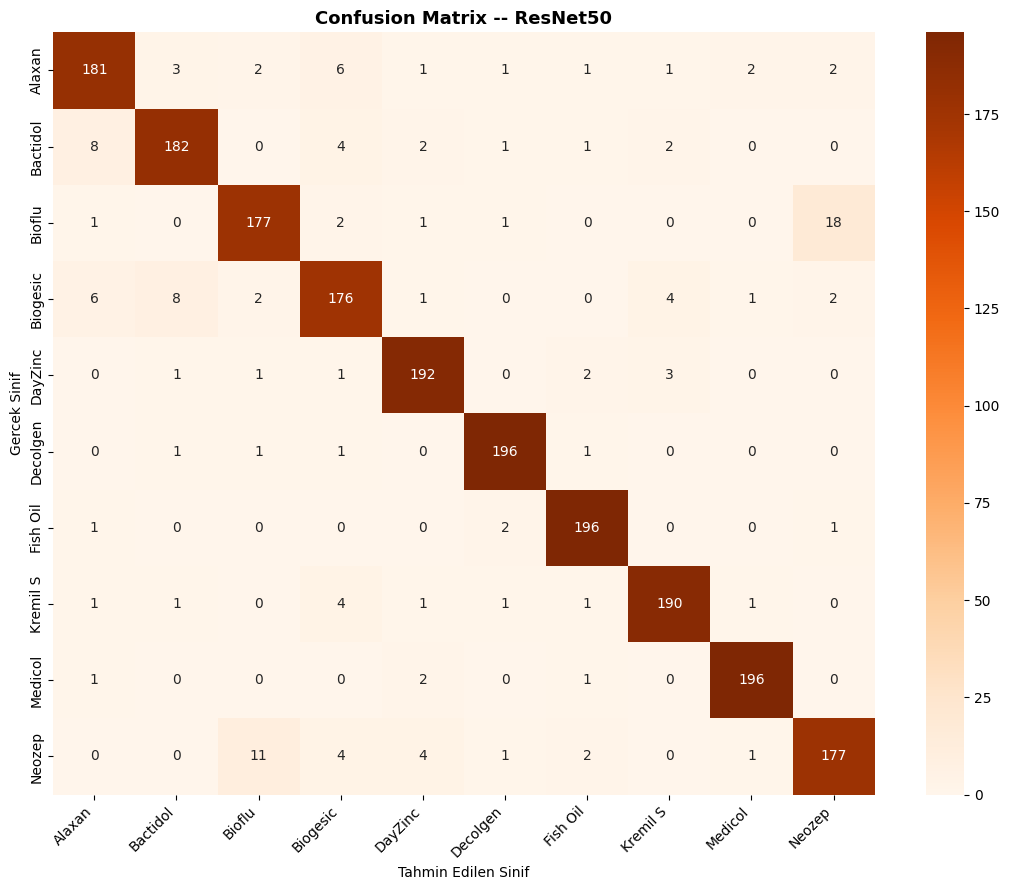

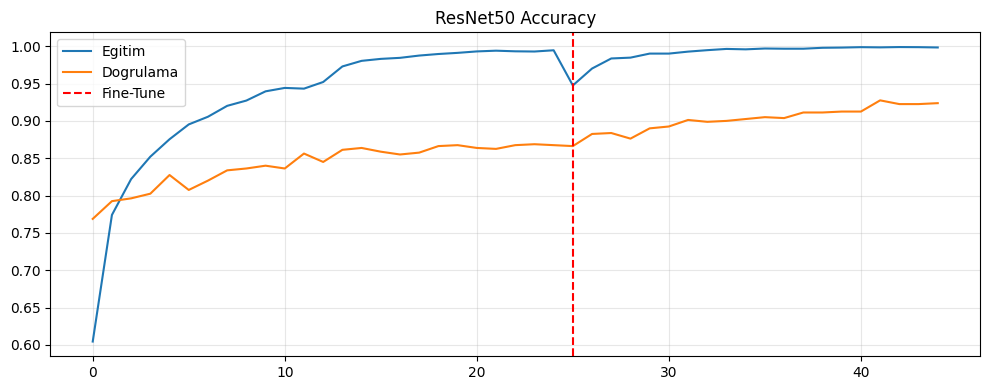

16321

In [9]:
# ── KOD HÜCRESİ 9: ResNet50 — Test Sonucu ve Grafik ───────────────────────
y_score_rn = model_rn.predict(X_test_rn, verbose=0)
y_pred_rn  = np.argmax(y_score_rn, axis=1)
rn_acc     = accuracy_score(y_test_num, y_pred_rn)

print('ResNet50 Siniflandirma Raporu:')
print(classification_report(y_test_num, y_pred_rn, target_names=siniflar))
print('ResNet50 TEST ACCURACY: %' + str(round(rn_acc*100, 2)))

cm_rn = confusion_matrix(y_test_num, y_pred_rn)
plt.figure(figsize=(11,9))
sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=siniflar, yticklabels=siniflar)
plt.title('Confusion Matrix -- ResNet50', fontsize=13, fontweight='bold')
plt.xlabel('Tahmin Edilen Sinif')
plt.ylabel('Gercek Sinif')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Egitim grafigi
acc_t  = hist_rn_1.history['accuracy']     + hist_rn_2.history['accuracy']
val_t  = hist_rn_1.history['val_accuracy'] + hist_rn_2.history['val_accuracy']
bolen  = len(hist_rn_1.history['accuracy'])

plt.figure(figsize=(10,4))
plt.plot(acc_t,  label='Egitim')
plt.plot(val_t,  label='Dogrulama')
plt.axvline(bolen, color='red', ls='--', lw=1.5, label='Fine-Tune')
plt.title('ResNet50 Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# RAM temizle
del X_train_rn, X_test_rn
gc.collect()

In [10]:
# ── KOD HÜCRESİ 10: Sadece Modeli Yükle ──
import tensorflow as tf
import os

model_yolu = os.path.join(MODEL_DIR, 'resnet50_hap_modeli.h5')

if os.path.exists(model_yolu):
    print(f'Model yükleniyor: {model_yolu}')
    # compile=False yapıyoruz çünkü sadece test/tahmin yapacağız, eğitmiyoruz.
    full_model = tf.keras.models.load_model(model_yolu, compile=False)
    print('Başarılı! Model tertemiz yüklendi.')
else:
    print('HATA: Model dosyası bulunamadı!')

Model yükleniyor: /content/drive/MyDrive/Hap_Modelleri_V3/resnet50_hap_modeli.h5
Başarılı! Model tertemiz yüklendi.
